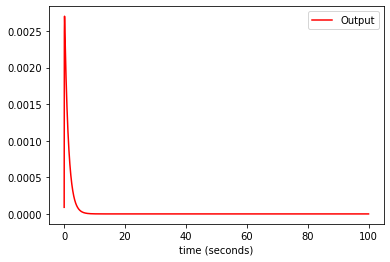

In [1]:
import sys
sys.path.append("../../")

from lib.data.dataplot import *
from lib.utils.time import *

class S1:
    
    def __init__(self):
        self.y = 0
        
    def evaluate(self, delta_t, _input):
        y = self.y - 0.5 * delta_t * self.y + 3 * delta_t * _input
        self.y = y
        return y

class S2:
    
    def __init__(self):
        self.x1 = 0
        self.x2 = 0
        
    def evaluate(self, delta_t, _input):
        new_x2 = self.x2 - delta_t * self.x2 - delta_t * self.x1 + delta_t * _input
        new_x1 = self.x1 + delta_t * self.x2
        self.x1 = new_x1
        self.x2 = new_x2
        return self.x1

class S3:
    
    def evaluate(self, delta_t, _input):
        return 10 * _input
    
    
class InnerLoop:
    
    def __init__(self):
        self.s1 = S1()
        self.s3 = S3()
        self.y = 0
        
    def evaluate(self, delta_t, _input):
        out_s3 = self.s3.evaluate(delta_t, self.y)
        in_s1 = _input - out_s3
        out_s1 = self.s1.evaluate(delta_t, in_s1)
        self.y = out_s1
        return self.y
    
class OuterLoop:

    def __init__(self):
        self.s1 = S1()
        self.inner_loop = InnerLoop()
        self.y = 0
        
    def evaluate(self, delta_t, _input):
        in_s1 = _input - self.y
        out_s1 = self.s1.evaluate(delta_t, in_s1)
        self.y = self.inner_loop.evaluate(delta_t, out_s1)
        return self.y

    
dp = DataPlotter()
dp.set_x("time (seconds)")
dp.add_y("out", "Output")

s = OuterLoop()
u = 10

t = Time(use_fake_time=True)
t.start()
while t.get() < 100:

    t.sleep(0.001)
    delta_t = t.elapsed()
    
    y = s.evaluate(delta_t, u)
    
    u = 0
    
    dp.append_x(t.get())
    dp.append_y("out", y)

dp.plot()